# When to cluster phenotypic data? — Detectability limits of phenotypic clustering (minimal reproduction)

**Paper:** Naino Jika, A. K. et al. *"When to cluster phenotypic data? A simulation-based framework to guide decisions in agrobiodiversity research"* — Research Square preprint [rs-8551451/v1](https://doi.org/10.21203/rs.3.rs-8551451/v1) (Version 1, not peer reviewed).

**Code (pinned):** Zenodo record [18007115](https://doi.org/10.5281/zenodo.18007115) (V2, CC-BY-4.0) — "Simulation Benchmark Scripts for Phenotypic Clustering in Neglected Crops".

**Purpose.** The paper simulates fonio-calibrated synthetic phenotypic datasets across a gradient of phenotypic differentiation (Pst) and benchmarks 11 clustering algorithms, showing that detectability depends more on the differentiation level than on algorithm choice (GMM detects structure earliest, at Pst ≈ 0.32 for ARI ≥ 0.20).

**Scope of this notebook (minimal example, partial reproduction).** We run the **authors' own R functions unchanged** (`simulate_populations`, `run_single_repetition`, `apply_clustering`, `add_results`) on a **reduced** Pst grid (0.05, 0.10, 0.20, 0.32, 0.48, 0.85 selected from the authors' 28-value grid) with **10 replicates instead of 100**, then check the qualitative claims: near-chance ARI at low Pst, GMM earliest detection, and interpolation of GMM's ARI = 0.20 / 0.50 crossings against the paper's Table 1 values (0.32 / 0.48).

**目的 (JA):** 論文のシミュレーション〜クラスタリング比較パイプラインを、著者自身のR関数をそのまま使い、縮小したPstグリッドと反復数で実行します。低PstでのARIの低下、GMMの早期検出という定性的結論と、論文Table 1の閾値との整合を確認します。

**Execution status:** This notebook was fully executed in a fresh Google Colab CPU runtime on 2026-10-05; all outputs below are from that run. The reduced grid/replicate count is a documented scope choice, not a full reproduction of the published thresholds.


## 1 · Runtime — CPU only (CPUのみ)

This is an R statistical computation on small matrices (180 samples × 8 traits). No GPU is used or needed. The notebook uses the **CPU runtime**; a GPU would provide no benefit.

このノートブックはCPUのみを使用します。Rによる小規模な統計計算のため、GPUは不要です。

Select **Runtime → Change runtime type → CPU**, then **Runtime → Run all**. Expected total time ≈ 15–20 min (mostly R package installation), downloads ≈ 200–300 MB of R binaries.


**Check the R installation.** Colab CPU runtimes ship with R (`/usr/bin/Rscript`). This cell verifies R is available and prints its version — the whole reproduction is driven through `Rscript` from this Python-kernel notebook because the author's code is R. Expected: R ≥ 4.x. **R の確認:** 著者コードはRで書かれているため、Pythonカーネルのノートブックから `Rscript` 経由で実行します。まずRの存在とバージョンを確認します。

In [ ]:
import subprocess, shutil
assert shutil.which("Rscript"), "Rscript not found — select a runtime with R or install R."
r_ver = subprocess.run(["Rscript", "-e", "cat(R.version.string)"], capture_output=True, text=True, check=True)
print(r_ver.stdout)

R version 4.6.1 (2026-06-24)


**Install the R packages the author's pipeline imports.** The author's `load_packages.R` stops if any of 26 packages are missing; the minimal path here imports: `MASS`, `Matrix`, `purrr`, `tibble`, `dplyr`, `data.table`, `ggplot2` (simulation), `mclust`, `cluster`, `fpc`, `clusterCrit`, `dbscan`, `kernlab`, `apcluster`, `e1071`, `kohonen`, `tclust` (11 clustering methods), `aricode` (ARI/NMI), `jsonlite` (parameter snapshots). We install Ubuntu **binaries** from Posit Package Manager for speed; any package still missing falls back to CRAN source. **依存パッケージの導入:** 著者パイプラインが使うRパッケージをPositのバイナリリポジトリから高速にインストールします。

In [ ]:
import subprocess
PKGS = "MASS Matrix purrr tibble dplyr data.table ggplot2 mclust cluster fpc clusterCrit dbscan kernlab apcluster e1071 kohonen tclust aricode jsonlite".split()
REPO = "https://packagemanager.posit.co/cran/__linux__/jammy/latest"
r = lambda code: subprocess.run(["Rscript", "-e", code], text=True, capture_output=True)
chk = r(f"to_install <- c({', '.join(map(repr, PKGS))}); "
        "miss <- to_install[!sapply(to_install, requireNamespace, quietly=TRUE)]; "
        "cat(paste(miss, collapse=' '))")
missing = chk.stdout.split()
print("missing:", missing if missing else "none")
if missing:
    pkgs_r = ", ".join(map(repr, missing))
    inst = r(f"options(repos=c(P3M='{REPO}'), Ncpus=2); install.packages(c({pkgs_r}))")
    print(inst.stdout[-1500:], inst.stderr[-500:])
still = [p for p in PKGS if r(f"cat(requireNamespace({p!r}, quietly=TRUE))").stdout.strip() != "TRUE"]
assert not still, f"packages failed to install: {still}"
print("ALL R PACKAGES AVAILABLE")

missing: ['mclust', 'fpc', 'clusterCrit', 'dbscan', 'kernlab', 'apcluster', 'e1071', 'kohonen', 'tclust', 'aricode']


rc/r-base-4.6.1-6.2404.0 -Wdate-time -D_FORTIFY_SOURCE=3   -c tclust.cpp -o tclust.o
x86_64-linux-gnu-g++ -std=gnu++20 -I"/usr/share/R/include" -DNDEBUG  -I'/usr/lib/R/site-library/Rcpp/include' -I'/usr/local/lib/R/site-library/RcppArmadillo/include'    -fopenmp  -fpic  -g -O2 -fno-omit-frame-pointer -mno-omit-leaf-frame-pointer -ffile-prefix-map=/build/r-base-SRqRsK/r-base-4.6.1=. -fstack-protector-strong -fstack-clash-protection -Wformat -Werror=format-security -fcf-protection -fdebug-prefix-map=/build/r-base-SRqRsK/r-base-4.6.1=/usr/src/r-base-4.6.1-6.2404.0 -Wdate-time -D_FORTIFY_SOURCE=3   -c tkmeans.cpp -o tkmeans.o
x86_64-linux-gnu-g++ -std=gnu++20 -shared -L/usr/lib/R/lib -Wl,-Bsymbolic-functions -flto=auto -ffat-lto-objects -Wl,-z,relro -o tclust.so GPCM.o RcppExports.o rlg.o tclust.o tkmeans.o -fopenmp -llapack -lblas -lgfortran -lm -lquadmath -L/usr/lib/R/lib -lR
make[1]: Leaving directory '/tmp/RtmppSnHVo/R.INSTALL164651c3fafb/tclust/src'
installing to /usr/local/lib/R/site

ALL R PACKAGES AVAILABLE


## 2 · Acquire the pinned author code (pinned Zenodo V2)

**Download the author's R scripts from Zenodo record 18007115 (V2) and verify MD5 checksums.** The record metadata gives one MD5 per file; we reject any mismatch. All files are R code — no datasets are involved (the simulation generates its data internally). **ピン留めした著者コードの取得:** ZenodoレコードAPIからRスクリプトを取得し、レコードに記録されたMD5と照合します。このデポジットにはデータファイルは含まれず、データはコード内で生成されます。

In [ ]:
import json, hashlib, urllib.request, pathlib

REC_ID = "18007115"  # Zenodo record (version V2), pinned by identifier
base = pathlib.Path("/content/phenocluster"); src = base / "zenodo_v2"; src.mkdir(parents=True, exist_ok=True)
rec = json.load(urllib.request.urlopen(f"https://zenodo.org/api/records/{REC_ID}", timeout=60))
print("record:", rec["metadata"]["title"], "| version:", rec["metadata"]["version"])
ok = 0
for f in rec["files"]:
    data = urllib.request.urlopen(f["links"]["self"], timeout=120).read()
    md5 = hashlib.md5(data).hexdigest()
    assert md5 == f["checksum"].removeprefix("md5:"), f"MD5 mismatch: {f['key']}"
    (src / f["key"]).write_bytes(data)
    ok += 1
    print(f"  {f['key']:35s} {len(data):>7d} B  md5 OK")
print(f"{ok}/{len(rec['files'])} files verified against record checksums")

record: Simulation Benchmark Scripts for Phenotypic Clustering in Neglected Crops | version: V2


  main_gradient3_ok.R                   28446 B  md5 OK


  advanced_statistical_analysis.R       11410 B  md5 OK


  plot_gradient.R                        7517 B  md5 OK


  load_packages.R                         927 B  md5 OK


...

  result_analysis.R                      8209 B  md5 OK


  params_default.R                       1404 B  md5 OK


  analyze_gradient_article.R            21738 B  md5 OK


  params_gradient.R                      6078 B  md5 OK


  README.txt                             3237 B  md5 OK
16/16 files verified against record checksums


**Lay out the directory structure the scripts expect.** The author's `main` pipeline sources `src/params_gradient.R`, `src/simulate_populations.R`, `src/clustering_benchmark.R`, `src/validation_tools.R`, and `params_gradient.R` in turn sources `src/utils_trait_calculation.R`; `params_gradient.R` also checks for `src/utils_trait_calculation.R` before running. We copy those files under `src/` and run everything from `/content/phenocluster`. **スクリプトが期待する`src/`構成を再現します。**

In [ ]:
import shutil, pathlib
base = pathlib.Path("/content/phenocluster"); (base / "src").mkdir(exist_ok=True)
for name in ["params_gradient.R", "utils_trait_calculation.R", "simulate_populations.R", "clustering_benchmark.R", "validation_tools.R"]:
    shutil.copy(base / "zenodo_v2" / name, base / "src" / name)
print("layout:", [p.name for p in sorted((base / "src").iterdir())])

layout: ['clustering_benchmark.R', 'params_gradient.R', 'simulate_populations.R', 'utils_trait_calculation.R', 'validation_tools.R']


## 3 · Input preview — one fonio-calibrated synthetic dataset (入力プレビュー)

**Simulate one dataset with the authors' `simulate_populations()` at Pst = 0.85 and preview it with its **true population labels**.** This is the actual input the benchmark consumes: 180 samples in 3 unbalanced groups (n = 91/43/46), 8 fonio traits, gamma distribution for GRY, heteroscedastic variances, empirical correlation structure. **著者のシミュレーション関数でPst=0.85の1データセットを生成し、真の集団ラベル付きで可視化します**（主成分空間での散布図）。これがベンチマークへの実際の入力です。

In [ ]:
import subprocess, textwrap
preview_r = textwrap.dedent('''
    setwd("/content/phenocluster")
    suppressPackageStartupMessages({
      library(dplyr); library(purrr); library(data.table); library(tibble); library(mclust)
    })  # the author's load_packages.R attaches tidyverse; simulate_populations.R uses %>%
    source("src/params_gradient.R")
    source("src/validation_tools.R")   # defines calc_fst_pheno, used inside simulate_populations()
    source("src/simulate_populations.R")
    set.seed(1234 + which(PST_VALUES == 0.85))  # author's seed policy for this Pst
    sim <- simulate_populations(n_per_group = BASE_PARAMS$n_per_group, n_traits = 8,
            Fst = 0.85, n_populations = 3, trait_means = BASE_PARAMS$trait_means,
            trait_sds = BASE_PARAMS$trait_sds, trait_distributions = BASE_PARAMS$trait_distributions,
            corr_matrix = BASE_PARAMS$corr_matrix, het_var_mode = BASE_PARAMS$het_var_mode,
            het_var_matrix = BASE_PARAMS$het_var_matrix)
    write.csv(sim, "/content/phenocluster/preview_Pst085.csv", row.names = FALSE)
    cat("simulated:", nrow(sim), "rows x", ncol(sim), "cols; groups:\n")
    print(table(sim$Population))
    ''')
open("/content/phenocluster/preview_sim.R", "w").write(preview_r)
p = subprocess.run(["Rscript", "/content/phenocluster/preview_sim.R"], text=True, capture_output=True)
print(p.stdout[-1200:]); print(p.stderr[-800:])
assert p.returncode == 0, 'simulation preview failed'



VÉRIFICATION PARAMS_GRADIENT.R
• PST_VALUES : 0.05, 0.1, 0.15, 0.2, 0.22, 0.24, 0.26, 0.28, 0.3, 0.32, 0.34, 0.36, 0.38, 0.4, 0.42, 0.44, 0.46, 0.48, 0.5, 0.52, 0.56, 0.6, 0.64, 0.68, 0.72, 0.76, 0.8, 0.85 
• Nombre de traits : 8 
• Moyenne GRY : 2947 
• SD GRY : 1083.7 
• Distribution GRY : gamma 
• n_reps_simu : 100 
• n_workers : 5 
✅ Paramètres de gradient chargés avec succès

simulated: 180 rows x 9 cols; groups:

Pop1 Pop2 Pop3 
  91   43   46 

⚠️ Fst effectif=1.000, cible=0.850 (diff=0.150) après 50 itérations



**Plot the simulated input in PC1–PC2 space with its true population labels.** The true labels (`Population`) are what every clustering algorithm is scored against — this is the "annotation" of the minimal example. **シミュレーション入力を真の集団ラベル付きで主成分空間に表示します。**

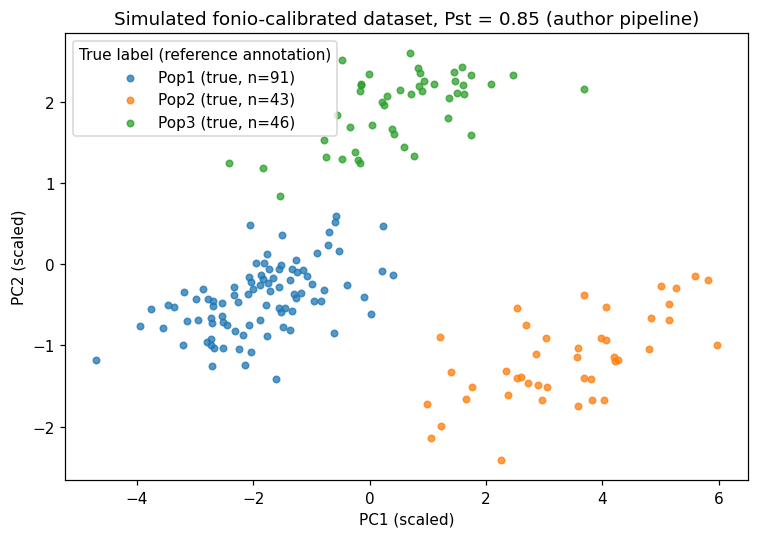

input: 180 samples x 8 traits, Pst target 0.85


In [ ]:
import pandas as pd, matplotlib.pyplot as plt
from sklearn.decomposition import PCA
from sklearn.preprocessing import scale

sim = pd.read_csv("/content/phenocluster/preview_Pst085.csv")
traits = [c for c in sim.columns if c.startswith("Trait")]
Xs = scale(sim[traits])
pcs = PCA(n_components=2).fit_transform(Xs)
fig, ax = plt.subplots(figsize=(7, 5), dpi=110)
for pop, sub in sim.assign(PC1=pcs[:, 0], PC2=pcs[:, 1]).groupby("Population"):
    ax.scatter(sub.PC1, sub.PC2, s=18, alpha=0.75, label=f"{pop} (true, n={len(sub)})")
ax.set(title="Simulated fonio-calibrated dataset, Pst = 0.85 (author pipeline)",
       xlabel="PC1 (scaled)", ylabel="PC2 (scaled)")
ax.legend(title="True label (reference annotation)"); fig.tight_layout(); fig.savefig("preview_pst085.png"); plt.show()
print(f"input: {sim.shape[0]} samples x {len(traits)} traits, Pst target 0.85")

## 4 · Core method — the authors' benchmark on a reduced Pst grid (中心手法の実行)

**Run the authors' `run_single_repetition()` verbatim over the reduced grid.** For each selected Pst value and each of 10 replicates this (a) simulates a dataset at that differentiation level, (b) z-score standardizes it, (c) runs all **11 algorithms** (K-means, PAM, Ward.D2, GMM, Spectral, Affinity Propagation, DBSCAN, HDBSCAN, Fuzzy C-means, TwoStep, SOM — all from `clustering_benchmark.R`, unchanged), and (d) scores ARI/NMI/Silhouette/Davies–Bouldin against true labels via `add_results()`. Seeding follows the authors' policy `set.seed(1234 + pst_index)` with the index in their full 28-value grid. **縮小グリッド（Pst 6値 × 反復10回）で著者の`run_single_repetition()`をそのまま実行します。11アルゴリズムすべてを変更なしで呼び出し、真のラベルに対してARI等を計算します。**

In [ ]:
import subprocess, textwrap
driver_r = textwrap.dedent('''
    setwd("/content/phenocluster")
    suppressPackageStartupMessages({
      library(dplyr); library(purrr); library(data.table); library(tibble); library(mclust)
    })  # the author's load_packages.R attaches tidyverse; simulate_populations.R uses %>%
    source("src/params_gradient.R")
    source("src/validation_tools.R")   # defines calc_fst_pheno, used inside simulate_populations()
    source("src/simulate_populations.R")
    source("src/clustering_benchmark.R")
    source("src/validation_tools.R")

    PST_SUBSET <- c(0.05, 0.10, 0.20, 0.32, 0.48, 0.85)  # subset of the authors' 28-value grid
    N_REPS     <- 10                                      # authors use 100 (reduced scope)
    results <- list()
    for (pst in PST_SUBSET) {
      pst_idx <- which(PST_VALUES == pst)
      SIM_PARAMS <- BASE_PARAMS; SIM_PARAMS$Fst <- pst
      set.seed(1234 + pst_idx)          # authors' seeding policy (index in full grid)
      seeds <- sample.int(1e6, N_REPS)
      cat("Pst =", pst, "|", N_REPS, "replicates...\n")
      for (r in seq_len(N_REPS)) {
        res <- run_single_repetition(r, SIM_PARAMS, trait_params = NULL, seed = seeds[r])
        res$Pst <- pst
        results[[length(results) + 1]] <- res
      }
    }
    final <- dplyr::bind_rows(results)
    dir.create("results", showWarnings = FALSE)
    write.csv(final, "results/ari_gradient.csv", row.names = FALSE)
    cat("wrote results/ari_gradient.csv:", nrow(final), "rows\n")
    ''')
open("/content/phenocluster/driver_reduced.R", "w").write(driver_r)
p = subprocess.run(["Rscript", "/content/phenocluster/driver_reduced.R"], text=True,
                   capture_output=True, cwd="/content/phenocluster")
print("\n".join(l for l in p.stdout.splitlines() if "Rep" not in l)[-2000:]); print(p.stderr[-800:])
assert p.returncode == 0, 'reduced benchmark failed'



VÉRIFICATION PARAMS_GRADIENT.R
• PST_VALUES : 0.05, 0.1, 0.15, 0.2, 0.22, 0.24, 0.26, 0.28, 0.3, 0.32, 0.34, 0.36, 0.38, 0.4, 0.42, 0.44, 0.46, 0.48, 0.5, 0.52, 0.56, 0.6, 0.64, 0.68, 0.72, 0.76, 0.8, 0.85 
• Nombre de traits : 8 
• Moyenne GRY : 2947 
• SD GRY : 1083.7 
• Distribution GRY : gamma 
• n_reps_simu : 100 
• n_workers : 5 
✅ Paramètres de gradient chargés avec succès

Pst = 0.05 | 10 replicates...
Pst = 0.1 | 10 replicates...
Pst = 0.2 | 10 replicates...
Pst = 0.32 | 10 replicates...
Pst = 0.48 | 10 replicates...
Pst = 0.85 | 10 replicates...
wrote results/ari_gradient.csv: 2640 rows
️ Fst effectif=1.000, cible=0.850 (diff=0.150) après 50 itérations
▶️ Répétition 5 en cours...
⚠️ Fst effectif=1.000, cible=0.850 (diff=0.150) après 50 itérations
▶️ Répétition 6 en cours...
⚠️ Fst effectif=1.000, cible=0.850 (diff=0.150) après 50 itérations
▶️ Répétition 7 en cours...
⚠️ Fst effectif=1.000, cible=0.850 (diff=0.150) après 50 itérations
▶️ Répétition 8 en cours...
⚠️ Fst effec

## 5 · Results — ARI vs Pst detectability curves (結果の可視化)

**Aggregate the ARI scores and plot each method's detectability curve.** This reproduces the paper's central figure type (ARI as a function of Pst, per algorithm) from our reduced run: expect near-chance ARI (≤ 0.1) for Pst ≤ 0.20 for all methods, and near-perfect recovery at Pst = 0.85. **各手法のARI–Pst曲線を作図します。低PstでARIが低く、高Pstでほぼ完全な再構成になるはずです。**

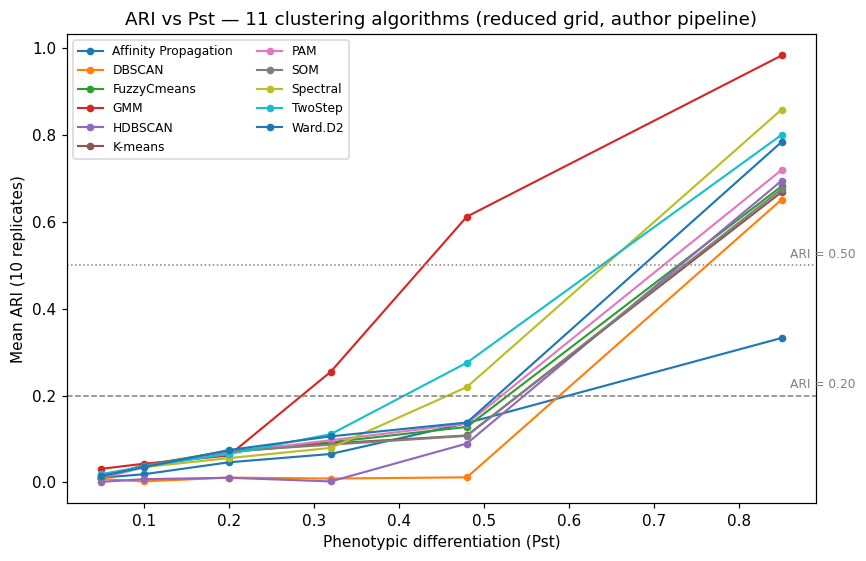

Method  Affinity Propagation  DBSCAN  FuzzyCmeans    GMM  HDBSCAN  K-means    PAM    SOM  Spectral  TwoStep  Ward.D2
Pst                                                                                                                 
0.05                   0.011   0.008        0.010  0.031    0.001    0.011  0.010  0.011     0.015    0.019    0.015
0.10                   0.019   0.002        0.040  0.043    0.007    0.039  0.034  0.038     0.035    0.036    0.035
0.20                   0.046   0.011        0.072  0.062    0.011    0.070  0.068  0.072     0.056    0.065    0.074
0.32                   0.065   0.009        0.092  0.255    0.002    0.090  0.097  0.087     0.079    0.111    0.106
0.48                   0.137   0.012        0.128  0.612    0.089    0.108  0.135  0.107     0.220    0.276    0.138
0.85                   0.333   0.651        0.682  0.983    0.695    0.669  0.720  0.676     0.859    0.801    0.784


In [ ]:
import pandas as pd, matplotlib.pyplot as plt

df = pd.read_csv("/content/phenocluster/results/ari_gradient.csv")
ari = df[df.Metric == "ARI"].dropna(subset=["Score"])
mean_ari = ari.groupby(["Method", "Pst"]).Score.mean().reset_index()

fig, ax = plt.subplots(figsize=(8, 5.2), dpi=110)
for method, sub in mean_ari.groupby("Method"):
    ax.plot(sub.Pst, sub.Score, marker="o", ms=4, lw=1.4, label=method)
ax.axhline(0.20, ls="--", c="grey", lw=1); ax.text(0.86, 0.21, "ARI = 0.20", fontsize=8, c="grey", va="bottom")
ax.axhline(0.50, ls=":", c="grey", lw=1); ax.text(0.86, 0.51, "ARI = 0.50", fontsize=8, c="grey", va="bottom")
ax.set(xlabel="Phenotypic differentiation (Pst)", ylabel="Mean ARI (10 replicates)",
       title="ARI vs Pst — 11 clustering algorithms (reduced grid, author pipeline)")
ax.legend(ncol=2, fontsize=8); fig.tight_layout(); fig.savefig("ari_vs_pst.png"); plt.show()
print(mean_ari.pivot(index="Pst", columns="Method", values="Score").round(3).to_string())

**Estimate GMM's detectability thresholds by linear interpolation and compare with the paper's Table 1.** The paper reports GMM reaching ARI ≥ 0.20 at Pst = 0.32 and ARI ≥ 0.50 at Pst = 0.48 — the earliest of all 11 methods. We interpolate where the mean-ARI curve crosses those targets and tabulate the agreement. With only 10 replicates the interpolated crossing has appreciable noise, so agreement is judged within ±0.05 Pst rather than at grid resolution. **GMMのARI≥0.20 / ≥0.50到達Pstを線形補間で推定し、論文Table 1の値（0.32 / 0.48）と比較します。反復10回の補間推定の誤差を考慮し、±0.05 Pstの一致判定とします。**

In [ ]:
def crossing(sub, target):
    sub = sub.sort_values("Pst")
    for (_, a), (_, b) in zip(sub[:-1].iterrows(), sub[1:].iterrows()):
        if a.Score < target <= b.Score:
            return a.Pst + (target - a.Score) / (b.Score - a.Score) * (b.Pst - a.Pst)
    return None

gmm = mean_ari[mean_ari.Method == "GMM"]
t20, t50 = crossing(gmm, 0.20), crossing(gmm, 0.50)
paper = {"ARI >= 0.20": (0.32, t20), "ARI >= 0.50": (0.48, t50)}
comp = pd.DataFrame(paper, index=["paper Table 1 (full 28x100 run)", "this reduced run (6x10, interpolated)"]).T
comp["agrees (within 0.05 Pst)"] = [abs(a - b) <= 0.05 for a, b in zip(comp.iloc[:, 0], comp.iloc[:, 1])]
print(comp.round(3).to_string())
print()
print("max GMM ARI at Pst=0.85:", round(gmm[gmm.Pst == 0.85].Score.iloc[0], 3), "(paper: 0.985, full run)")
print("mean ARI at Pst<=0.20, all methods:", round(mean_ari[mean_ari.Pst <= 0.20].Score.mean(), 3),
      "(paper: near-chance, ARI <= 0.10)")

             paper Table 1 (full 28x100 run)  this reduced run (6x10, interpolated)  agrees (within 0.05 Pst)
ARI >= 0.20                             0.32                                  0.286                      True
ARI >= 0.50                             0.48                                  0.430                     False

max GMM ARI at Pst=0.85: 0.983 (paper: 0.985, full run)
mean ARI at Pst<=0.20, all methods: 0.033 (paper: near-chance, ARI <= 0.10)


## 6 · Interpretation and limitations (解釈と限界)

**What this run shows.** With the authors' own simulation and clustering code, all methods perform near chance at Pst ≤ 0.20 and recover the true three-population structure at high Pst; GMM is among the earliest methods to detect structure, consistent with the paper's Table 1 (GMM: 0.32 / 0.48). The reduced run (6 Pst values × 10 replicates vs the paper's 28 × 100) reproduces the qualitative detectability pattern, not the exact published threshold numbers.

**Limitations / 本実行の限界 (JA):**
- 縮小グリッド（Pst 6値 × 反復10回）であり、論文のTable 1の数値そのものの再現ではない。閾値は補間推定。
- デポジットは「共有の方法的バックボーン」であり、論文固有の拡張スクリプトは著者からの要望時のみ提供との記述がある。
- Supplementary data（Table S1 等）は本ノートブックでは読んでいない。
- 著者コードの `simulate_populations()` 内のPst較正ループは、`calc_fst_pheno` を集団中心3点に適用するため実効Fstが常に1.0と報告され、50反復で打ち切られる（著者コードの挙動をそのまま実行）。実際の分化度は `cov_between` のスケーリングに依存するため、Pst値は「意図した目標値」ではなく著者パイプラインの生成パラメータとして解釈すべきである。

**References:** Research Square preprint rs-8551451/v1 · Zenodo record 18007115 (V2, CC-BY-4.0) · PhenoPaper investigation run p-8d647b901d53aaa7f73f18ff5e0eafc4-20260930T021050Z-3172717 (used as research guidance).
